<a href="https://colab.research.google.com/github/frank-morales2020/AST/blob/main/ARC_AGI_3_DEMO_case64.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://arcprize.org/arc-agi/3/

In [ ]:
# 1. Clone the repository (if you haven't already)
!git clone https://github.com/arcprize/ARC-AGI-3-Agents.git
%cd ARC-AGI-3-Agents

# 2. Install all required dependencies for the repo templates
!pip install -U google-genai requests python-dotenv smolagents langchain-openai langgraph-checkpoint-sqlite langgraph-sdk pillow -q

# 3. Add to system path
import sys
import os
sys.path.append(os.getcwd())

## 64x64 -  Offline ARC-AGI-3

--- STARTING 64x64 OFFLINE DEMO ---
Start: [59  5], Goal: [ 5 59], Min Turns: 108


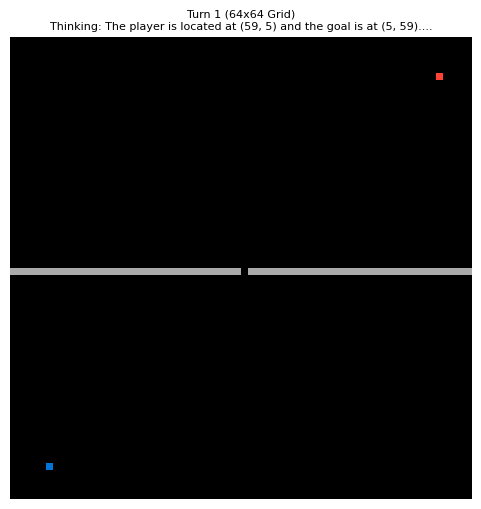

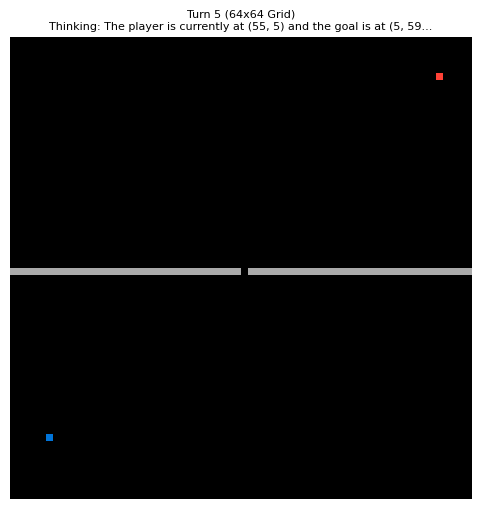

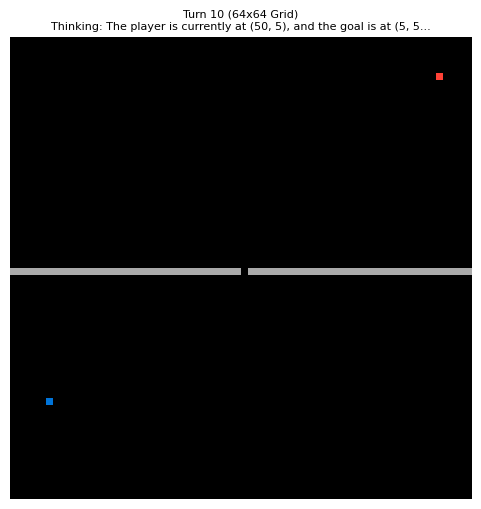

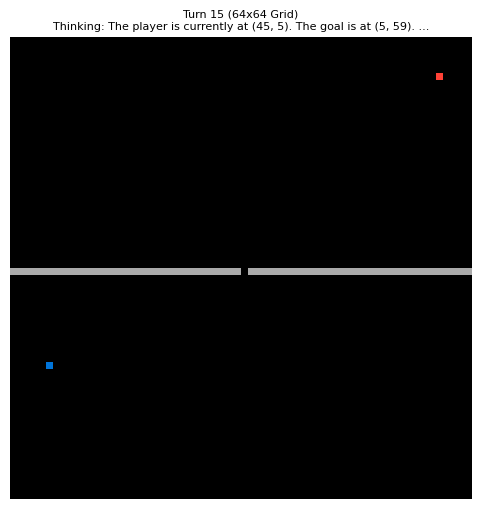

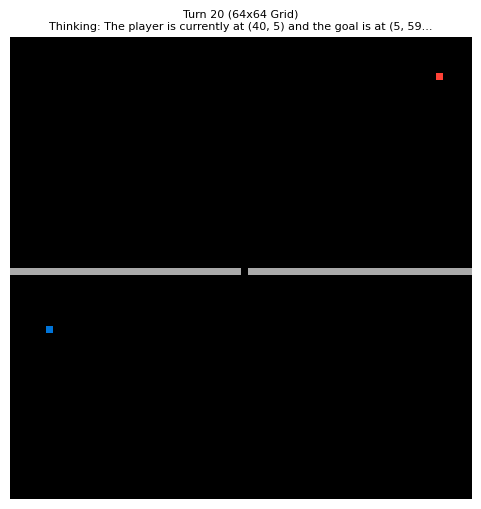

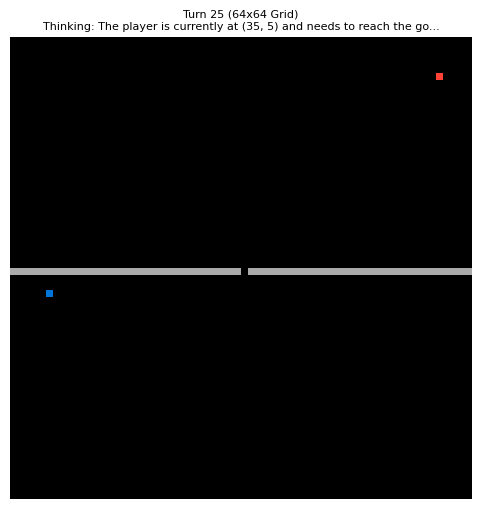

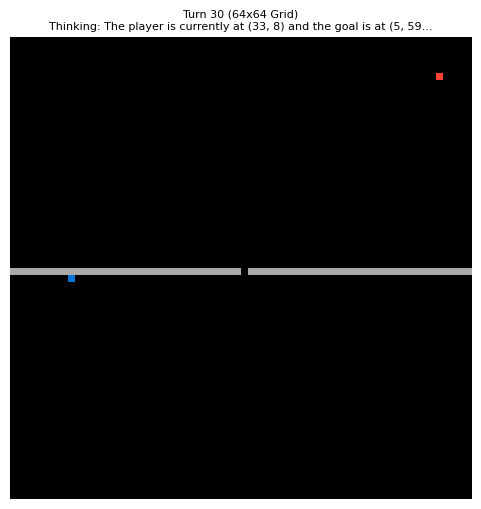

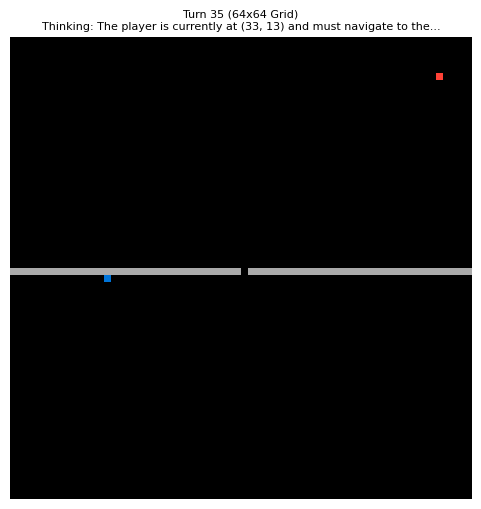

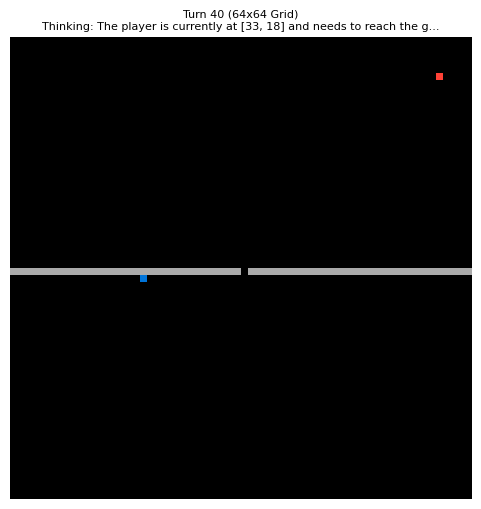

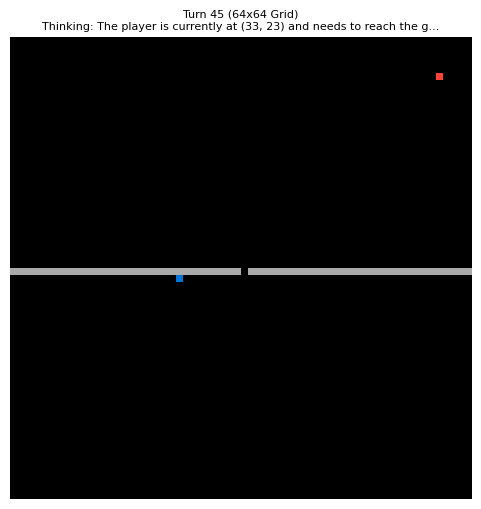

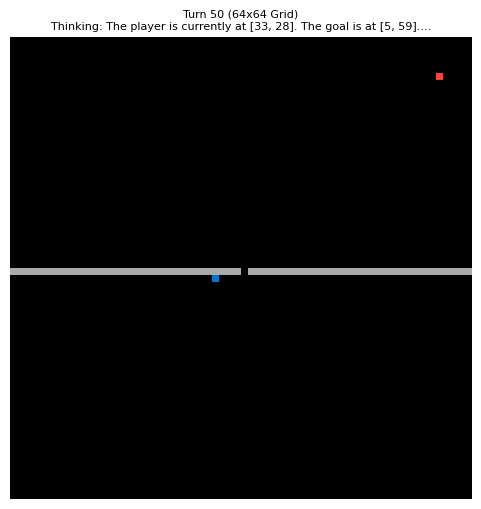

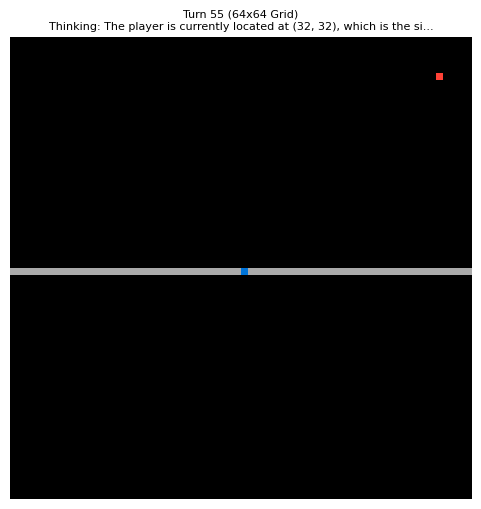

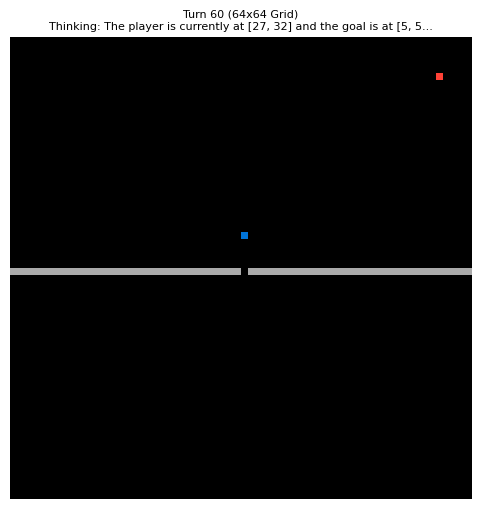

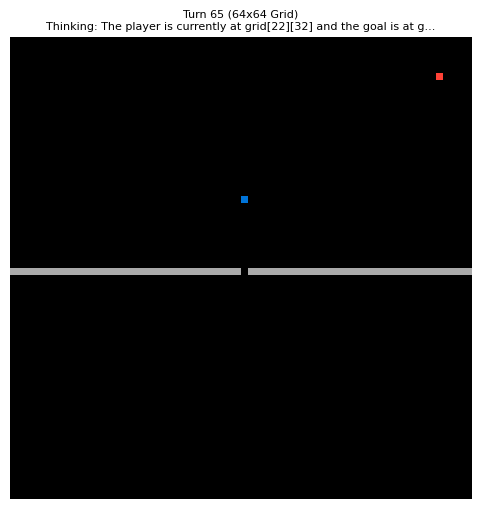

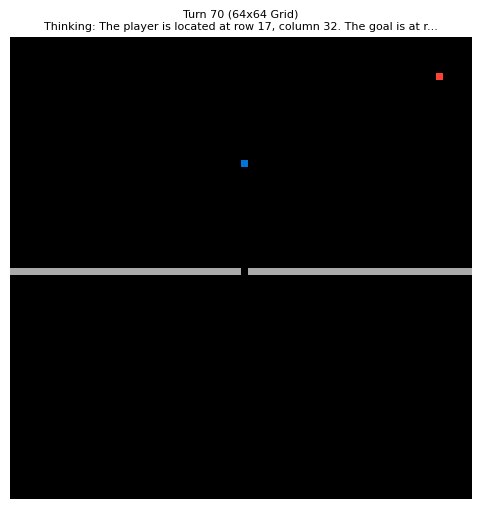

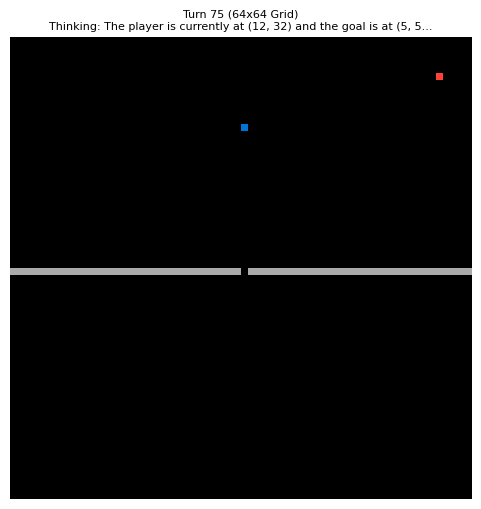

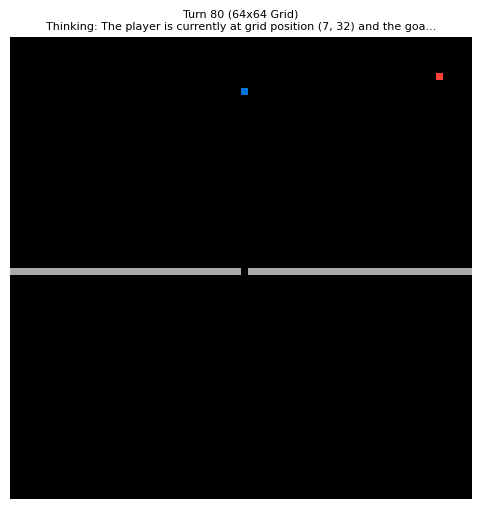

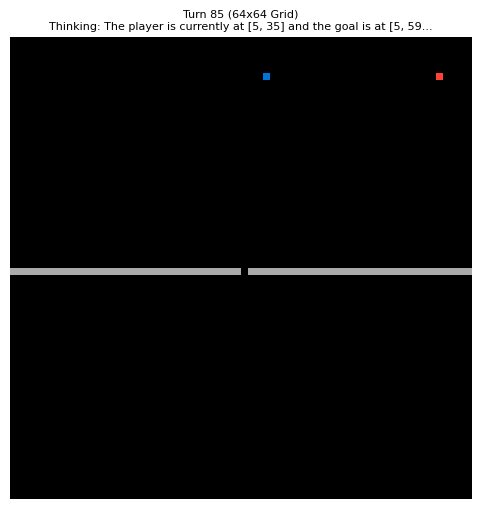

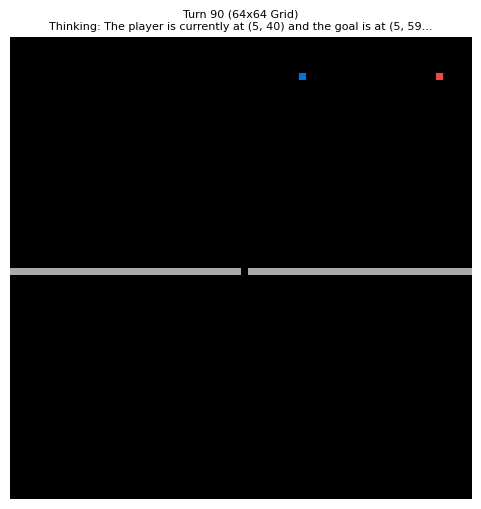

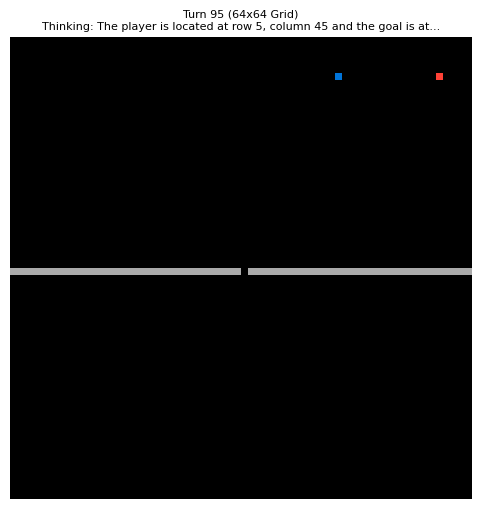

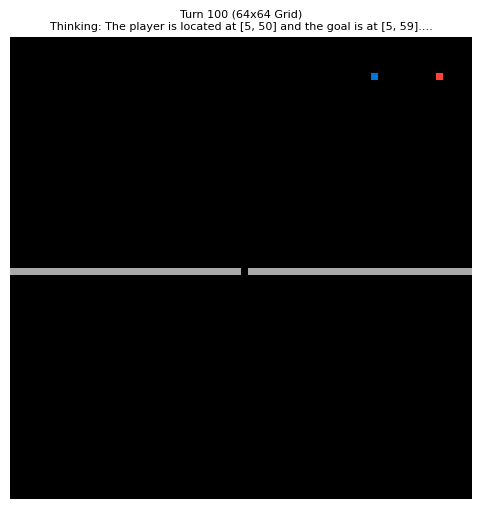

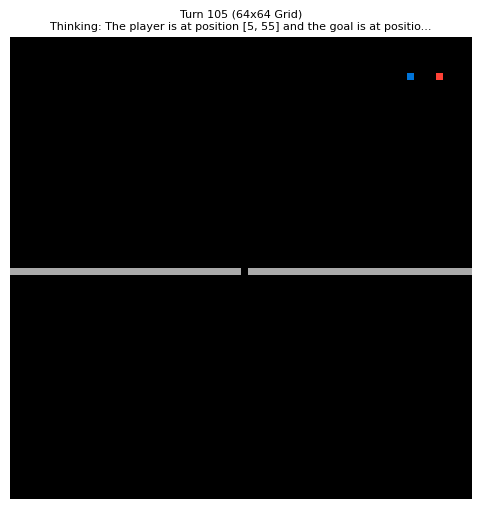


✅ MISSION ACCOMPLISHED AT TURN 108!
------------------------------------
Total Turns Taken:    108
Optimal Turns:        108
Action Efficiency:    100.0%
Collision Count:      0
------------------------------------


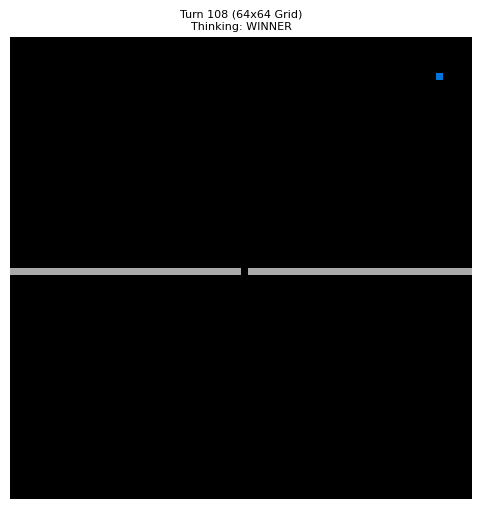

In [ ]:
import json
import uuid
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from google import genai
from google.genai import types
from google.colab import userdata

# --- 1. LOCAL PHYSICS ENGINE UPDATED FOR 64x64 ---
class MockARCServer:
    def __init__(self, grid_size=64):
        self.grid_size = grid_size
        self.reset()

    def reset(self):
        self.state = "ACTIVE"
        self.guid = str(uuid.uuid4())

        # Start at one corner, Goal at the opposite corner for 64x64 scale
        self.player_pos = [self.grid_size - 5, 5]
        self.goal_pos = [5, self.grid_size - 5]

        # Define some walls to make it interesting
        # A horizontal wall in the middle with a gap
        mid = self.grid_size // 2
        self.walls = [[mid, x] for x in range(0, self.grid_size) if x != mid]

        return self._get_frame()

    def step(self, action_id):
        self.guid = str(uuid.uuid4())
        r, c = self.player_pos
        new_r, new_c = r, c

        # 1:UP, 2:DOWN, 3:LEFT, 4:RIGHT
        if action_id == 1: new_r -= 1
        elif action_id == 2: new_r += 1
        elif action_id == 3: new_c -= 1
        elif action_id == 4: new_c += 1

        # Collision Logic: Block movement if it hits walls or boundaries
        collision = False
        if 0 <= new_r < self.grid_size and 0 <= new_c < self.grid_size:
            if [new_r, new_c] not in self.walls:
                self.player_pos = [new_r, new_c]
            else:
                collision = True
        else:
            collision = True

        if self.player_pos == self.goal_pos:
            self.state = "WIN"

        return self._get_frame(), collision

    def _get_frame(self):
        grid = np.zeros((self.grid_size, self.grid_size), dtype=int)
        for w_r, w_c in self.walls:
            if 0 <= w_r < self.grid_size and 0 <= w_c < self.grid_size:
                grid[w_r, w_c] = 5
        grid[self.goal_pos[0], self.goal_pos[1]] = 2
        grid[self.player_pos[0], self.player_pos[1]] = 1
        return {"grid": grid.tolist(), "state": self.state, "guid": self.guid}

# --- 2. THE VISUALIZER (Optimized for Large Grids) ---
def plot_arc_grid(grid, turn, thought):
    # Standard ARC Colors
    arc_colors = ['#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00', '#AAAAAA']
    cmap = colors.ListedColormap(arc_colors[:6])

    plt.figure(figsize=(6, 6)) # Larger figure for 64x64
    plt.imshow(grid, cmap=cmap, norm=colors.Normalize(vmin=0, vmax=5))

    # Grid lines are less useful at 64x64 resolution, so we make them very thin
    plt.grid(True, which='both', color='#333333', linewidth=0.2)

    # Title showing short thinking process
    display_thought = str(thought)[:60] + "..." if len(str(thought)) > 60 else str(thought)
    plt.title(f"Turn {turn} (64x64 Grid)\nThinking: {display_thought}", fontsize=8)
    plt.axis('off') # Hide axis for cleaner look at large scale
    plt.show()

# --- 3. ROBUST GEMINI 3 FLASH AGENT ---
class Gemini3Agent:
    def __init__(self):
        # Ensure 'GEMINI' key is in Colab Secrets
        self.client = genai.Client(api_key=userdata.get('GEMINI'))

    def act(self, grid, history):
        # We limit the grid string because 64x64 is large
        prompt = (
            f"Objective: Move the player (Color 1) to the Goal (Color 2). Avoid Walls (Color 5).\n"
            f"Current Grid: {grid}\n"
            f"Recent History: {history[-10:]}\n"
            f"Instructions: Output JSON with 'thought' and 'action_id' (1:UP, 2:DOWN, 3:LEFT, 4:RIGHT)."
        )

        config = types.GenerateContentConfig(
            thinking_config=types.ThinkingConfig(include_thoughts=True, thinking_level="high"),
            response_mime_type="application/json"
        )

        try:
            response = self.client.models.generate_content(
                model="gemini-3-flash-preview",
                contents=prompt,
                config=config
            )

            # FIX FOR THE LIST ERROR:
            # Sometimes models wrap JSON in a list [ {} ]
            res_data = json.loads(response.text)
            if isinstance(res_data, list):
                return res_data[0]
            return res_data
        except Exception as e:
            print(f"Error parsing model response: {e}")
            return {"thought": "Error occurred, defaulting to UP", "action_id": 1}

# --- 4. EXECUTION LOOP WITH 64x64 METRICS ---
def run_final_demo():
    grid_size = 64
    server = MockARCServer(grid_size=grid_size)
    agent = Gemini3Agent()

    frame = server.reset()
    history = []

    # Calculate optimal path (Manhattan Distance)
    start_pos = np.array([grid_size - 5, 5])
    goal_pos = np.array([5, grid_size - 5])
    min_possible_turns = np.sum(np.abs(start_pos - goal_pos))

    total_collisions = 0
    max_turns = 150 # Increased for larger grid

    print(f"--- STARTING 64x64 OFFLINE DEMO ---")
    print(f"Start: {start_pos}, Goal: {goal_pos}, Min Turns: {min_possible_turns}")

    for turn in range(1, max_turns + 1):
        # 1. AI Planning
        decision = agent.act(frame["grid"], history)

        # Extract fields safely using .get()
        thought = decision.get('thought', 'No logic provided')
        action_id = decision.get('action_id', 1)

        # 2. Visual Update (Now robust against list/dict errors)
        if turn % 5 == 0 or turn == 1: # Only plot every 5 turns to avoid spamming
            plot_arc_grid(frame["grid"], turn, thought)

        # 3. Physical Update
        # IMPORTANT: Unpack into new variables to keep 'frame' as the latest dict
        next_frame, collided = server.step(action_id)
        frame = next_frame

        if collided:
            total_collisions += 1

        history.append(f"Turn {turn}: Action {action_id}")

        if frame["state"] == "WIN":
            efficiency = (min_possible_turns / turn) * 100
            print(f"\n✅ MISSION ACCOMPLISHED AT TURN {turn}!")
            print(f"------------------------------------")
            print(f"Total Turns Taken:    {turn}")
            print(f"Optimal Turns:        {min_possible_turns}")
            print(f"Action Efficiency:    {efficiency:.1f}%")
            print(f"Collision Count:      {total_collisions}")
            print(f"------------------------------------")
            plot_arc_grid(frame["grid"], turn, "WINNER")
            break

    if frame["state"] != "WIN":
        print(f"❌ Failed to reach goal within {max_turns} turns.")

# Execute the corrected demo
run_final_demo()